# A small hotel simulator

I model daily pricing for 10 rooms and one arrival date. I check how a price choice changes revenue, inventory, and time, then inspect a saved record of those decisions.

In [1]:
from pathlib import Path
from dataclasses import asdict
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from gymnasium.utils.env_checker import check_env

# Find the project even when this notebook is opened from its version folder.
ROOT = Path.cwd()
while not (ROOT / 'data/source.json').exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError('Open this notebook inside the hotel pricing project')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'versions/Sep_25_v1'))  # Frozen v1 implementation.

from hotel_pricing.environment import HotelPricingEnv, load_config, sale_probability
from hotel_pricing.offline_data import load_dataset

OUT = ROOT / 'outputs/simulator'
OUT.mkdir(parents=True, exist_ok=True)
config = load_config()
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. The assumed hotel

- One arrival date, one stay night, and 10 rooms.
- Up to 330 daily decisions, with prices 55, 70, 90, 110, and 125.
- At most one sale per day; no cancellations or seasonality.
- At price 90, sale probability is `12 / 330` per day. The price-response slope is 4.

I plot the assumed probability at each price. The [specification](../../versions/Sep_25_v1/docs/environment_spec.md) records why these settings were chosen.

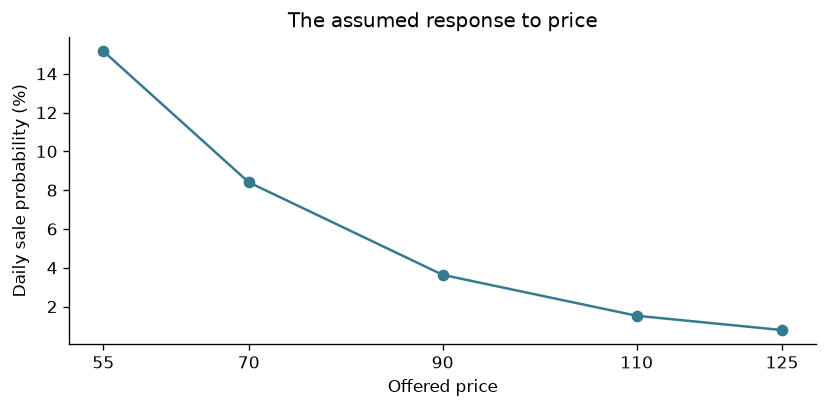

In [2]:
prices = np.asarray(config.prices)
probabilities = np.array([sale_probability(config, price) for price in prices])
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(prices, probabilities * 100, 'o-', color='#357a91')
ax.set(xticks=prices, xlabel='Offered price', ylabel='Daily sale probability (%)',
       title='The assumed response to price')
fig.tight_layout()
fig.savefig(OUT / 'assumed_response.png')
plt.show()

Lower prices make sales more likely. The 12 expected sales at price 90 are counted before inventory limits; only 10 rooms can actually sell. This curve defines the simulated customer response, not measured guest behavior.

## 2. One pricing decision

The **state** is `[days left, rooms left]`. An **action** is a price index, and the **reward** is that day's sales revenue.

Gymnasium's `reset()` starts at `[330, 10]`. `step(action)` runs one day. Action 2 offers the third price, 90:

- Sale: reward 90, next state `[329, 9]`.
- No sale: reward 0, next state `[329, 10]`.

I use seed 7 to make the random example repeatable.

In [3]:
env = HotelPricingEnv(config)
check_env(env, skip_render_check=True)  # Check that Gymnasium can use this environment.

state, _ = env.reset(seed=7)
action = 2  # The third price in the menu is 90.
next_state, reward, terminated, truncated, info = env.step(action)

print('Before:', state.tolist())
print('Offered price:', info['price'])
print('Rooms sold:', info['sold'])
print('Revenue:', reward)
print('After:', next_state.tolist())
print('Episode ended:', terminated)
env.close()

Before: [330, 10]
Offered price: 90
Rooms sold: 0
Revenue: 0.0
After: [329, 10]
Episode ended: False


Time passes even without a sale, so no-sale days must also be recorded. `terminated` marks sellout or the last day. `truncated` would mark an outside interruption and stays False here. `info` records the price and sale outcome.

**A complete selling window**

An **episode** repeats the daily decision until sellout or the last day. I run one episode at a fixed price of 90 and add its rewards.

In [4]:
env = HotelPricingEnv(config)
state, _ = env.reset(seed=7)
episode_ended = False
total_revenue = 0
days_used = 0

while not episode_ended:
    action = 2  # Always offer 90 for this example.
    state, reward, terminated, truncated, info = env.step(action)
    total_revenue += reward
    days_used += 1
    episode_ended = terminated or truncated

env.close()
print('Days used:', days_used)
print('Total revenue:', total_revenue)
print('Rooms left:', state[1])

Days used: 188
Total revenue: 900.0
Rooms left: 0


The loop stops at sellout or the end of the window. Total revenue is the sum of actual sales, not the sum of offered prices.

## 3. Save the experience

A **policy** chooses a price. The **behavior policy** collects our data by randomly selecting prices 55, 70, 90, 110, and 125 with probabilities 10%, 15%, 50%, 15%, and 10%.

Each saved transition contains `state, action, reward, next state`, and an ending flag. The 2,000 collected episodes are split by shuffled episode ID:

- 1,600 for training.
- 200 for validation.
- 200 for testing after models are fixed.

All days from an episode stay together. This split concerns simulated decisions, not the year-based split of real bookings. I read the existing files rather than collect new data.

In [5]:
DATA = ROOT / 'data/simulated/hotel_v1'
manifest = json.loads((DATA / 'manifest.json').read_text())

# The saved data must belong to the environment we are describing.
current_config = asdict(config)
current_config['prices'] = list(config.prices)
assert manifest['config'] == current_config

# Loading also checks that the saved file has not changed.
train = load_dataset(DATA, 'train')
validation = load_dataset(DATA, 'validation')
test = load_dataset(DATA, 'test')

train_ids = set(train['episode_id'])
validation_ids = set(validation['episode_id'])
test_ids = set(test['episode_id'])
assert train_ids.isdisjoint(validation_ids)
assert train_ids.isdisjoint(test_ids)
assert validation_ids.isdisjoint(test_ids)

for name in ['train', 'validation', 'test']:
    split = manifest['files'][name]
    print(f"{name}: {split['episodes']:,} episodes, {split['transitions']:,} daily decisions")

train: 1,600 episodes, 324,260 daily decisions
validation: 200 episodes, 40,688 daily decisions
test: 200 episodes, 40,110 daily decisions


In [6]:
steps = pd.DataFrame({
    'episode': train['episode_id'],
    'periods_left': train['observations'][:, 0],
    'rooms_left': train['observations'][:, 1],
    'price': prices[train['actions']],
    'revenue': train['rewards'],
    'next_periods_left': train['next_observations'][:, 0],
    'next_rooms_left': train['next_observations'][:, 1],
    'ended': train['terminated'],
})
steps.head(8)

,episode,periods_left,rooms_left,price,revenue,next_periods_left,next_rooms_left,ended
0,0,330,10,110,0.0,329,10,False
1,0,329,10,70,0.0,328,10,False
2,0,328,10,90,0.0,327,10,False
3,0,327,10,70,0.0,326,10,False
4,0,326,10,110,0.0,325,10,False
5,0,325,10,90,0.0,324,10,False
6,0,324,10,110,0.0,323,10,False
7,0,323,10,125,0.0,322,10,False


The saved rows include days without sales. Separate episodes stay in separate splits, so the same selling window cannot appear in both training and testing.

## 4. Data coverage

I count price choices and visits to each time-and-inventory state. Darker cells have more visits; the logarithmic scale keeps rare visits visible.

**Coverage** is the share of reachable state–price pairs with at least one example. Trying every price somewhere does not mean trying every price at every state.

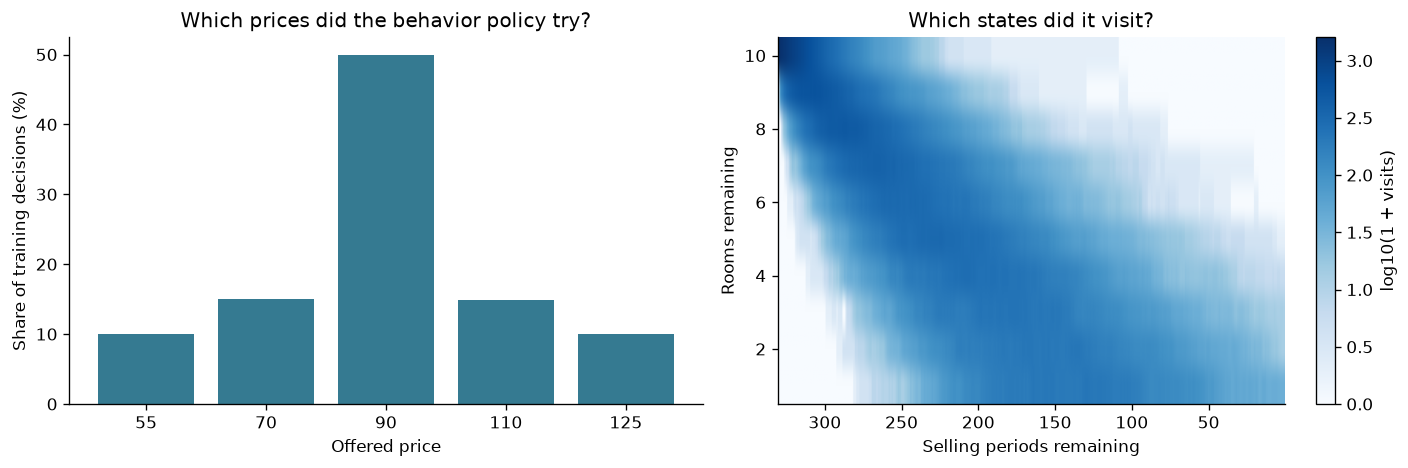

- **No-sale days:** 95.1% of training decisions.
- **State–price coverage:** 73.0% of 16,275 reachable combinations were visited at least once.
- **Average final occupancy:** 99.3% under this behavior policy.

In [7]:
# Count how often each time / inventory / price combination appears.
# Grouping saved rows avoids a Python loop over hundreds of thousands of days.
counts_by_state = steps.groupby(['periods_left', 'rooms_left', 'price']).size()
visits = np.zeros((config.horizon + 1, config.capacity + 1, len(prices)), dtype=int)
for (time_left, rooms_left, price), count in counts_by_state.items():
    action = config.prices.index(price)
    visits[time_left, rooms_left, action] = count

price_counts = steps['price'].value_counts().reindex(prices, fill_value=0)
price_shares = price_counts / len(steps) * 100
state_visits = visits[1:, 1:].sum(axis=2)
plot_colors = np.log10(1 + state_visits.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(prices.astype(str), price_shares, color='#357a91')
axes[0].set(xlabel='Offered price', ylabel='Share of training decisions (%)',
            title='Which prices did the behavior policy try?')
heat = axes[1].imshow(plot_colors,
                      origin='lower', aspect='auto', extent=[0.5, config.horizon + 0.5, 0.5, config.capacity + 0.5], cmap='Blues')
axes[1].invert_xaxis()
axes[1].set(xlabel='Selling periods remaining', ylabel='Rooms remaining',
            title='Which states did it visit?')
fig.colorbar(heat, ax=axes[1], label='log10(1 + visits)')
fig.tight_layout()
fig.savefig(OUT / 'training_coverage.png')
plt.show()

stats = manifest['files']['train']
display(Markdown(
    f"- **No-sale days:** {stats['no_sale_fraction']:.1%} of training decisions.\n"
    f"- **State–price coverage:** {stats['state_action_coverage']:.1%} of "
    f"{stats['reachable_state_action_pairs']:,} reachable combinations were visited at least once.\n"
    f"- **Average final occupancy:** {stats['mean_final_occupancy']:.1%} under this behavior policy."
))

All five prices appear, but some state–price pairs are missing. Most days have no sale, even though most rooms eventually sell. A single visit counts as covered; it does not give a reliable estimate of an action's value.

## 5. One recorded episode

I plot the first episode in the training file. This shows how random price choices, sales, and remaining inventory fit together.

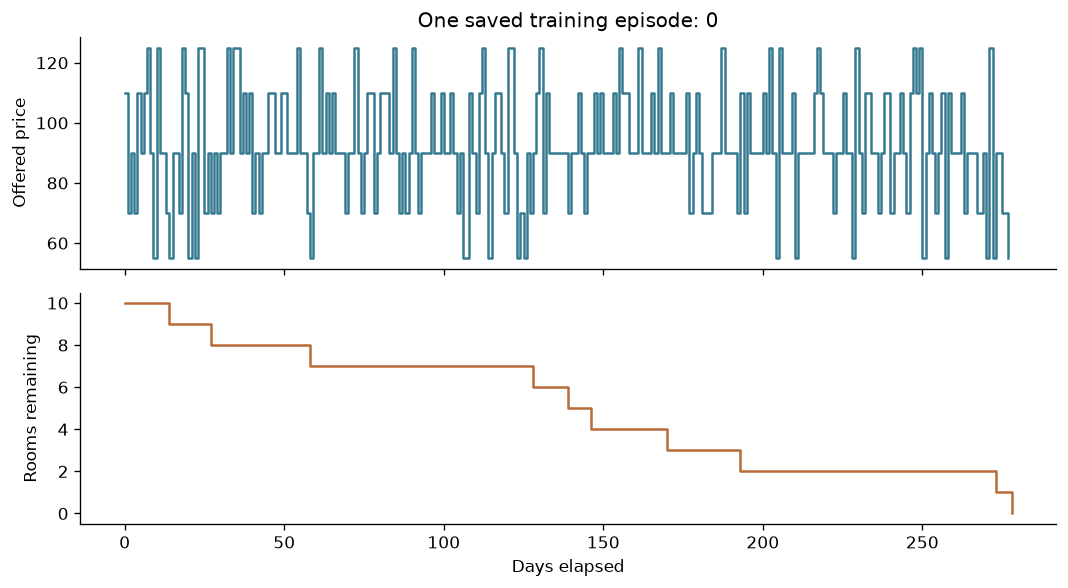

Days: 278, revenue: 750, rooms left: 0


In [8]:
episode_id = train['episode_id'][0]
mask = train['episode_id'] == episode_id
days = train['step'][mask]
rooms_after_each_day = train['next_observations'][mask, 1]
rooms = np.concatenate([[config.capacity], rooms_after_each_day])
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].step(days, prices[train['actions'][mask]], where='post', color='#357a91')
axes[0].set(ylabel='Offered price', title=f'One saved training episode: {episode_id}')
axes[1].step(np.arange(len(rooms)), rooms, where='post', color='#b66b38')
axes[1].set(xlabel='Days elapsed', ylabel='Rooms remaining', ylim=(-0.5, 10.5))
fig.tight_layout()
fig.savefig(OUT / 'saved_episode.png')
plt.show()
print(f"Days: {mask.sum()}, revenue: {train['rewards'][mask].sum():g}, rooms left: {rooms[-1]}")

The recorded episode shows the full sequence: choose a price, observe a possible sale, update inventory, and repeat. The fixed dataset preserves these outcomes for inspection and learning.